# Data Cleaning — Crop Pest Early Warning System
**Input:** `agriculture_dataset.csv` (raw, unmodified)
**Output:** `cleaned_crop_pest_dataset.csv`
**Scope:** Rice, Wheat, Maize (already the only crops present in the raw data)

This notebook performs **cleaning only**. It does **not** create the Low/Medium/High
pest-risk target and does **not** train any machine learning model — both come later.

Every cleaning decision below is documented with:
- **What** was wrong
- **How many rows** were affected
- **Why** we chose that fix (clip vs. drop vs. convert vs. keep)
- Rows are **never blindly deleted** — we only remove rows when there is no
  defensible way to repair the value, which turns out to not be necessary anywhere
  in this dataset (all issues are fixable by capping to a valid physical range).

## 0. Setup & Load the Original Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

# Always load the ORIGINAL, untouched file
df_raw = pd.read_csv('agriculture_dataset.csv')

# Work on a copy so the raw data stays untouched for reference/comparison
df = df_raw.copy()

print(f"Raw dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Raw dataset loaded: 212019 rows, 32 columns


### Snapshot of the raw data (for later before/after comparison)

In [2]:
before_shape = df.shape
before_describe = df.describe().T.copy()
print(before_shape)
before_describe

(212019, 32)


,count,mean,std,min,25%,50%,75%,max
High_Resolution_RGB,212019.0,0.200232,0.400175,0.000000e+00,0.000000,0.000000,0.000000,1.000000
Multispectral_Images,212019.0,0.299714,0.458134,0.000000e+00,0.000000,0.000000,1.000000,1.000000
Thermal_Images,212019.0,0.399492,0.489795,0.000000e+00,0.000000,0.000000,1.000000,1.000000
Temporal_Images,212019.0,0.100430,0.300573,0.000000e+00,0.000000,0.000000,0.000000,1.000000
Spatial_Resolution,212019.0,1.200244,0.499427,-9.597324e-01,0.862755,1.199967,1.538014,3.344946
GPS_Coordinates,212019.0,550433.748268,260335.476601,1.000030e+05,324279.000000,550668.000000,776122.000000,999986.000000
Field_Boundaries,212019.0,2.599946,0.663463,1.000000e+00,2.000000,3.000000,3.000000,3.000000
Elevation_Data,212019.0,54.948326,25.969531,1.000003e+01,32.550718,54.840251,77.443205,99.999944
Canopy_Coverage,212019.0,49.942370,49.925445,2.365532e-04,14.368852,34.544415,69.375661,582.456962
NDVI,212019.0,0.500288,0.149984,-1.652591e-01,0.398988,0.500420,0.600887,1.158040


---
## 1. Fix Impossible Values

We inspect and repair each physically-impossible value **before** doing anything else,
so every later step works on realistic data.

**General policy:** We prefer *clipping* (capping) impossible values to the nearest
valid boundary over deleting rows, because:
- The invalid part is usually confined to a single column, while the rest of the row's
  data (weather, soil, other indices) is perfectly usable.
- Several of the affected columns affect a meaningful % of rows — dropping them would
  throw away a lot of legitimate information in other columns for no benefit.
- Clipping preserves dataset size for the eventual ML pipeline, and is a standard,
  transparent, reversible way to enforce domain-valid ranges.

### 1a. `Expected_Yield` — Negative Values

Yield (kg/ha or similar) **cannot be negative** in the real world.

In [3]:
neg_yield_mask = df['Expected_Yield'] < 0
n_neg_yield = neg_yield_mask.sum()
print(f"Rows with negative Expected_Yield: {n_neg_yield} ({n_neg_yield/len(df)*100:.4f}% of data)")
print(df.loc[neg_yield_mask, 'Expected_Yield'].describe())

Rows with negative Expected_Yield: 18 (0.0085% of data)
count     18.000000
mean    -131.034577
std      139.693229
min     -468.653721
25%     -236.715965
50%      -81.823364
75%      -14.756861
max       -0.074524
Name: Expected_Yield, dtype: float64


**Decision:** Clip negative values to `0`. Only 18 rows (0.008%) are affected — a
negligible fraction. Clipping to the physical floor (0 = no yield) is more defensible
than deleting the row (which would throw away otherwise-valid weather/soil/pest data)
or than inventing a value via imputation.

> Note: `Expected_Yield` will later be **dropped entirely** as a leakage feature (Section 3).
> We still fix it here because the raw column should never contain physically impossible
> values regardless of what happens to it downstream — and this documents the issue for
> the record.

In [4]:
df['Expected_Yield'] = df['Expected_Yield'].clip(lower=0)

# Verify
print("Remaining negative values:", (df['Expected_Yield'] < 0).sum())
print(df['Expected_Yield'].describe())

Remaining negative values: 0
count    212019.000000
mean       3003.467434
std         797.625758
min           0.000000
25%        2467.295493
50%        3003.479378
75%        3539.738947
max        6684.320978
Name: Expected_Yield, dtype: float64


### 1b. `Spatial_Resolution` — Negative Values

Spatial resolution is a physical distance/measurement value (e.g., meters per pixel) and
**cannot be negative**.

In [5]:
neg_sr_mask = df['Spatial_Resolution'] < 0
n_neg_sr = neg_sr_mask.sum()
print(f"Rows with negative Spatial_Resolution: {n_neg_sr} ({n_neg_sr/len(df)*100:.3f}% of data)")
print(df.loc[neg_sr_mask, 'Spatial_Resolution'].describe())

Rows with negative Spatial_Resolution: 1738 (0.820% of data)
count    1738.000000
mean       -0.165289
std         0.145752
min        -0.959732
25%        -0.233907
50%        -0.126282
75%        -0.054180
max        -0.000071
Name: Spatial_Resolution, dtype: float64


**Decision:** Clip negative values to `0`. 1,738 rows (0.82%) are affected — small
enough that clipping is safe and preserves the rest of each row's valid information.

> Note: like `Expected_Yield`, this column is later **dropped as leakage/irrelevant
> imaging metadata** (Section 3). We still correct it here for completeness and to keep
> the "impossible value" audit trail accurate.

In [6]:
df['Spatial_Resolution'] = df['Spatial_Resolution'].clip(lower=0)

print("Remaining negative values:", (df['Spatial_Resolution'] < 0).sum())
print(df['Spatial_Resolution'].describe())

Remaining negative values: 0
count    212019.000000
mean          1.201599
std           0.495757
min           0.000000
25%           0.862755
50%           1.199967
75%           1.538014
max           3.344946
Name: Spatial_Resolution, dtype: float64


### 1c. `Canopy_Coverage` — Values Above 100%

`Canopy_Coverage` is a percentage and must lie within **0–100**.

In [7]:
over_cc_mask = df['Canopy_Coverage'] > 100
n_over_cc = over_cc_mask.sum()
print(f"Rows with Canopy_Coverage > 100%: {n_over_cc} ({n_over_cc/len(df)*100:.2f}% of data)")
print(df.loc[over_cc_mask, 'Canopy_Coverage'].describe())

Rows with Canopy_Coverage > 100%: 28652 (13.51% of data)
count    28652.000000
mean       149.916365
std         49.675949
min        100.000916
25%        114.529681
50%        134.485875
75%        169.274187
max        582.456962
Name: Canopy_Coverage, dtype: float64


**Decision:** Clip to a **maximum of 100**. This affects 28,652 rows (13.5%) — far
too many to drop without losing a huge amount of legitimate data in every other column.
Since canopy coverage is bounded by definition (you cannot cover more than 100% of the
ground), capping at the logical ceiling is the correct fix, not an arbitrary one.

In [8]:
df['Canopy_Coverage'] = df['Canopy_Coverage'].clip(upper=100)

print("Remaining values > 100:", (df['Canopy_Coverage'] > 100).sum())
print(df['Canopy_Coverage'].describe())

Remaining values > 100: 0
count    212019.000000
mean         43.196731
std          33.189006
min           0.000237
25%          14.368852
50%          34.544415
75%          69.375661
max         100.000000
Name: Canopy_Coverage, dtype: float64


### 1d. `NDVI` — Values Outside Valid Range

NDVI (Normalized Difference Vegetation Index) is mathematically bounded to **[-1, 1]**
by construction (it's a ratio of reflectance differences over their sum). Negative NDVI
is valid (water, snow, bare soil), so we use the full physical bound of **-1 to 1**,
not the "0 to 1" range sometimes assumed for healthy vegetation only.

In [9]:
ndvi_out_mask = ~df['NDVI'].between(-1, 1)
n_ndvi_out = ndvi_out_mask.sum()
print(f"Rows with NDVI outside [-1, 1]: {n_ndvi_out} ({n_ndvi_out/len(df)*100:.3f}% of data)")
print(df.loc[ndvi_out_mask, 'NDVI'].describe())

Rows with NDVI outside [-1, 1]: 108 (0.051% of data)
count    108.000000
mean       1.033787
std        0.032971
min        1.000336
25%        1.008384
50%        1.023105
75%        1.049927
max        1.158040
Name: NDVI, dtype: float64


**Decision:** Clip to `[-1, 1]`. Only 108 rows (0.05%) are affected, and all violations
are on the upper side (max was 1.158). Clipping to the mathematical bound is the correct,
non-arbitrary fix.

In [10]:
df['NDVI'] = df['NDVI'].clip(lower=-1, upper=1)

print("Remaining out-of-range NDVI values:", (~df['NDVI'].between(-1, 1)).sum())
print(df['NDVI'].describe())

Remaining out-of-range NDVI values: 0
count    212019.000000
mean          0.500271
std           0.149923
min          -0.165259
25%           0.398988
50%           0.500420
75%           0.600887
max           1.000000
Name: NDVI, dtype: float64


### 1e. `SAVI` — Range Check

SAVI (Soil-Adjusted Vegetation Index) is also bounded to approximately **[-1, 1]**.

In [11]:
savi_out_mask = ~df['SAVI'].between(-1, 1)
n_savi_out = savi_out_mask.sum()
print(f"Rows with SAVI outside [-1, 1]: {n_savi_out}")
print(df['SAVI'].describe())

Rows with SAVI outside [-1, 1]: 0
count    212019.000000
mean          0.399978
std           0.120172
min          -0.088355
25%           0.319258
50%           0.399942
75%           0.480787
max           0.979315
Name: SAVI, dtype: float64


**Decision:** No action needed — **0 rows** violate the valid SAVI range. We still
run this check explicitly rather than assuming it's clean, to keep the audit complete.

### 1f. Additional Sanity Checks (Humidity, Soil_pH, Wind_Speed, Rainfall, Temperature)

Quick confirmation that no other columns hide impossible values.

In [12]:
sanity_checks = {
    'Humidity outside [0,100]': (~df['Humidity'].between(0, 100)).sum(),
    'Soil_pH outside [3.5,9]': (~df['Soil_pH'].between(3.5, 9)).sum(),
    'Wind_Speed negative': (df['Wind_Speed'] < 0).sum(),
    'Rainfall negative': (df['Rainfall'] < 0).sum(),
    'Temperature outside [-10,55]': (~df['Temperature'].between(-10, 55)).sum(),
    'Soil_Moisture outside [0,100]': (~df['Soil_Moisture'].between(0, 100)).sum(),
    'Organic_Matter negative': (df['Organic_Matter'] < 0).sum(),
    'Weed_Coverage negative': (df['Weed_Coverage'] < 0).sum(),
    'Pest_Damage outside [0,100]': (~df['Pest_Damage'].between(0, 100)).sum(),
    'Crop_Stress_Indicator outside [0,100]': (~df['Crop_Stress_Indicator'].between(0, 100)).sum(),
}
pd.Series(sanity_checks, name='Violations')

Humidity outside [0,100]                 0
Soil_pH outside [3.5,9]                  0
Wind_Speed negative                      0
Rainfall negative                        0
Temperature outside [-10,55]             0
Soil_Moisture outside [0,100]            0
Organic_Matter negative                  0
Weed_Coverage negative                   0
Pest_Damage outside [0,100]              0
Crop_Stress_Indicator outside [0,100]    0
Name: Violations, dtype: int64

**Result:** All of these are clean (0 violations) — no further numeric repairs needed.

---
## 2. Correct Data Types & Convert Categorical/Boolean Columns

Several columns are stored as `int64` but are conceptually categorical or boolean flags,
not continuous numbers. We fix the dtype **only for columns we are keeping** — columns
that will be dropped as leakage in Section 3 are not worth converting first.

### Columns we keep, with corrected types:
| Column | Old type | New type | Reason |
|---|---|---|---|
| `Crop_Type` | object | `category` | Nominal categorical (Rice/Wheat/Maize) |
| `Crop_Growth_Stage` | int64 | ordered `category` | Ordinal stage (1→2→3→4), not a magnitude to average |
| `Pest_Hotspots` | int64 (0/1) | `bool` | True binary flag |
| `Drainage_Features` | int64 (0/1) | `bool` | True binary flag |

### Columns whose dtype we do NOT bother fixing (dropped in Section 3 anyway):
`High_Resolution_RGB`, `Multispectral_Images`, `Thermal_Images`, `Temporal_Images`,
`Field_Boundaries`, `Ground_Truth_Segmentation`, `Bounding_Boxes`, `GPS_Coordinates`,
`Spatial_Resolution`, `Expected_Yield`, `Crop_Health_Label`.

In [13]:
print("Before conversion:")
print(df[['Crop_Type', 'Crop_Growth_Stage', 'Pest_Hotspots', 'Drainage_Features']].dtypes)

Before conversion:
Crop_Type              str
Crop_Growth_Stage    int64
Pest_Hotspots        int64
Drainage_Features    int64
dtype: object


In [14]:
df['Crop_Type'] = df['Crop_Type'].astype('category')

growth_order = [1, 2, 3, 4]
df['Crop_Growth_Stage'] = pd.Categorical(df['Crop_Growth_Stage'], categories=growth_order, ordered=True)

df['Pest_Hotspots'] = df['Pest_Hotspots'].astype(bool)
df['Drainage_Features'] = df['Drainage_Features'].astype(bool)

print("After conversion:")
print(df[['Crop_Type', 'Crop_Growth_Stage', 'Pest_Hotspots', 'Drainage_Features']].dtypes)

After conversion:
Crop_Type            category
Crop_Growth_Stage    category
Pest_Hotspots            bool
Drainage_Features        bool
dtype: object


In [15]:
print("Crop_Type categories:", df['Crop_Type'].cat.categories.tolist())
print("Crop_Growth_Stage categories (ordered):", df['Crop_Growth_Stage'].cat.categories.tolist())
print("Pest_Hotspots unique:", df['Pest_Hotspots'].unique())
print("Drainage_Features unique:", df['Drainage_Features'].unique())

Crop_Type categories: ['Maize', 'Rice', 'Wheat']
Crop_Growth_Stage categories (ordered): [1, 2, 3, 4]


Pest_Hotspots unique: [False  True]
Drainage_Features unique: [False  True]


---
## 3. Investigate `GPS_Coordinates`

`GPS_Coordinates` is stored as a **single integer column**, not a real latitude/longitude
pair.

In [16]:
print(df_raw['GPS_Coordinates'].describe())
print()
print("Sample raw values:", df_raw['GPS_Coordinates'].head(10).tolist())
print()
print("Min:", df_raw['GPS_Coordinates'].min(), " Max:", df_raw['GPS_Coordinates'].max())
print("Unique values:", df_raw['GPS_Coordinates'].nunique(), "out of", len(df_raw), "rows")

count    212019.000000
mean     550433.748268
std      260335.476601
min      100003.000000
25%      324279.000000
50%      550668.000000
75%      776122.000000
max      999986.000000
Name: GPS_Coordinates, dtype: float64

Sample raw values: [201538, 215854, 890802, 605584, 871732, 251493, 665471, 899698, 300672, 452663]

Min: 100003  Max: 999986
Unique values: 188726 out of 212019 rows


**Findings:**
- Real GPS coordinates require **two separate values** (latitude: -90 to 90, longitude:
  -180 to 180), usually with decimal precision. Here we have **one single integer** per
  row, ranging from ~100,000 to ~999,986.
- This range looks like a synthetic/random ID generator (`randint(100000, 999999)` style),
  not any real coordinate system.
- It is not decomposable into a valid lat/long pair, and it doesn't align with any known
  coordinate encoding (e.g., geohash, UTM).

**Decision: Remove `GPS_Coordinates`.**
It carries no genuine geographic meaning we can use for pest-risk modeling, and keeping a
high-cardinality pseudo-ID (188,726 nearly-unique values across 212,019 rows) would only
risk overfitting/leakage if accidentally used as a feature. This matches the removal list
in Section 4 below.

---
## 4. Remove Leakage / Irrelevant Columns

The following columns are removed because they represent **imaging/annotation metadata**,
**downstream outcomes**, or **non-informative pseudo-IDs** — none of which are legitimate
causal inputs for predicting pest risk.

| Column | Category | Why removed |
|---|---|---|
| `High_Resolution_RGB` | Imaging metadata | Flags which sensor imagery was captured, not a field/pest condition |
| `Multispectral_Images` | Imaging metadata | Same as above |
| `Thermal_Images` | Imaging metadata | Same as above |
| `Temporal_Images` | Imaging metadata | Same as above |
| `Spatial_Resolution` | Imaging metadata | Describes sensor resolution, not a crop/pest condition |
| `GPS_Coordinates` | Pseudo-ID | Not real geolocation (see Section 3); high-cardinality ID risks leakage |
| `Field_Boundaries` | Annotation metadata | Describes boundary annotation, not a pest-risk driver |
| `Ground_Truth_Segmentation` | Annotation metadata | Computer-vision labeling artifact, irrelevant to tabular pest prediction |
| `Bounding_Boxes` | Annotation metadata | Computer-vision labeling artifact, irrelevant to tabular pest prediction |
| `Expected_Yield` | Downstream outcome | Yield is a *result* of pest damage/growing conditions, not a cause — using it risks reverse-causality leakage |
| `Crop_Health_Label` | Downstream outcome / leakage | A consequence of pest damage and other stressors; using it as a feature when predicting pest risk would leak the outcome |

We keep everything else: crop identity/stage, weather, soil, remote-sensing vegetation
indices, and the pest-related columns themselves.

In [17]:
columns_to_drop = [
    'High_Resolution_RGB', 'Multispectral_Images', 'Thermal_Images', 'Temporal_Images',
    'Spatial_Resolution', 'GPS_Coordinates', 'Field_Boundaries',
    'Ground_Truth_Segmentation', 'Bounding_Boxes', 'Expected_Yield', 'Crop_Health_Label'
]

print(f"Dropping {len(columns_to_drop)} columns:")
for c in columns_to_drop:
    print(f"  - {c}")

df_cleaned = df.drop(columns=columns_to_drop)
print(f"\nShape before drop: {df.shape}")
print(f"Shape after drop:  {df_cleaned.shape}")

Dropping 11 columns:
  - High_Resolution_RGB
  - Multispectral_Images
  - Thermal_Images
  - Temporal_Images
  - Spatial_Resolution
  - GPS_Coordinates
  - Field_Boundaries
  - Ground_Truth_Segmentation
  - Bounding_Boxes
  - Expected_Yield
  - Crop_Health_Label

Shape before drop: (212019, 32)
Shape after drop:  (212019, 21)


---
## 5. Final Feature Set Kept for the Pest Early Warning System

In [18]:
print("Columns retained:")
for i, c in enumerate(df_cleaned.columns, 1):
    print(f"{i:2d}. {c} ({df_cleaned[c].dtype})")

Columns retained:
 1. Elevation_Data (float64)
 2. Canopy_Coverage (float64)
 3. NDVI (float64)
 4. SAVI (float64)
 5. Chlorophyll_Content (float64)
 6. Leaf_Area_Index (float64)
 7. Crop_Stress_Indicator (int64)
 8. Temperature (float64)
 9. Humidity (float64)
10. Rainfall (float64)
11. Wind_Speed (float64)
12. Soil_Moisture (float64)
13. Soil_pH (float64)
14. Organic_Matter (float64)
15. Pest_Hotspots (bool)
16. Weed_Coverage (float64)
17. Pest_Damage (int64)
18. Crop_Growth_Stage (category)
19. Crop_Type (category)
20. Water_Flow (float64)
21. Drainage_Features (bool)


These fall into four groups relevant to pest-risk prediction:
- **Crop context:** `Crop_Type`, `Crop_Growth_Stage`
- **Environmental drivers:** `Temperature`, `Humidity`, `Rainfall`, `Wind_Speed`, `Soil_Moisture`, `Soil_pH`, `Organic_Matter`, `Elevation_Data`, `Water_Flow`, `Drainage_Features`
- **Remote-sensing / plant-condition indicators:** `NDVI`, `SAVI`, `Chlorophyll_Content`, `Leaf_Area_Index`, `Canopy_Coverage`, `Crop_Stress_Indicator`, `Weed_Coverage`
- **Pest-related columns (candidate targets, kept as-is — no target engineering yet):** `Pest_Damage`, `Pest_Hotspots`

---
## 6. Re-Verify the Cleaned Dataset

Repeating the full original checklist (rows/columns, missing values, duplicates, dtypes,
impossible values, categorical/numerical variables) on `df_cleaned`.

### 6a. Rows and Columns

In [19]:
print(f"Rows: {df_cleaned.shape[0]}")
print(f"Columns: {df_cleaned.shape[1]}")
print(f"(Raw dataset was: {before_shape[0]} rows, {before_shape[1]} columns)")

Rows: 212019
Columns: 21
(Raw dataset was: 212019 rows, 32 columns)


### 6b. Missing Values

In [20]:
missing_after = df_cleaned.isnull().sum()
print("Total missing values across all columns:", missing_after.sum())
missing_after

Total missing values across all columns: 0


Elevation_Data           0
Canopy_Coverage          0
NDVI                     0
SAVI                     0
Chlorophyll_Content      0
Leaf_Area_Index          0
Crop_Stress_Indicator    0
Temperature              0
Humidity                 0
Rainfall                 0
Wind_Speed               0
Soil_Moisture            0
Soil_pH                  0
Organic_Matter           0
Pest_Hotspots            0
Weed_Coverage            0
Pest_Damage              0
Crop_Growth_Stage        0
Crop_Type                0
Water_Flow               0
Drainage_Features        0
dtype: int64

### 6c. Duplicate Records

In [21]:
dupe_after = df_cleaned.duplicated().sum()
print(f"Duplicate rows after cleaning: {dupe_after}")

Duplicate rows after cleaning: 0


### 6d. Data Types

In [22]:
dtype_after = pd.DataFrame({'Column': df_cleaned.columns, 'Dtype': df_cleaned.dtypes.astype(str).values})
dtype_after

,Column,Dtype
0,Elevation_Data,float64
1,Canopy_Coverage,float64
2,NDVI,float64
3,SAVI,float64
4,Chlorophyll_Content,float64
5,Leaf_Area_Index,float64
6,Crop_Stress_Indicator,int64
7,Temperature,float64
8,Humidity,float64
9,Rainfall,float64


### 6e. Impossible Values — Re-check

In [23]:
final_checks = {
    'Negative Expected_Yield': 'column removed',
    'Negative Spatial_Resolution': 'column removed',
    'Canopy_Coverage > 100%': (df_cleaned['Canopy_Coverage'] > 100).sum(),
    'NDVI outside [-1,1]': (~df_cleaned['NDVI'].between(-1, 1)).sum(),
    'SAVI outside [-1,1]': (~df_cleaned['SAVI'].between(-1, 1)).sum(),
    'Humidity outside [0,100]': (~df_cleaned['Humidity'].between(0, 100)).sum(),
    'Pest_Damage outside [0,100]': (~df_cleaned['Pest_Damage'].between(0, 100)).sum(),
}
pd.Series(final_checks, name='Result')

Negative Expected_Yield        column removed
Negative Spatial_Resolution    column removed
Canopy_Coverage > 100%                      0
NDVI outside [-1,1]                         0
SAVI outside [-1,1]                         0
Humidity outside [0,100]                    0
Pest_Damage outside [0,100]                 0
Name: Result, dtype: object

### 6f. Categorical Variables

In [24]:
categorical_final = df_cleaned.select_dtypes(include=['category', 'bool']).columns.tolist()
print("Categorical / boolean columns:")
for c in categorical_final:
    print(f" - {c} ({df_cleaned[c].dtype})")

Categorical / boolean columns:


 - Pest_Hotspots (bool)
 - Crop_Growth_Stage (category)
 - Crop_Type (category)
 - Drainage_Features (bool)


### 6g. Numerical Variables

In [25]:
numerical_final = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:")
for c in numerical_final:
    print(f" - {c} ({df_cleaned[c].dtype})")

Numerical columns:
 - Elevation_Data (float64)
 - Canopy_Coverage (float64)
 - NDVI (float64)
 - SAVI (float64)
 - Chlorophyll_Content (float64)
 - Leaf_Area_Index (float64)
 - Crop_Stress_Indicator (int64)
 - Temperature (float64)
 - Humidity (float64)
 - Rainfall (float64)
 - Wind_Speed (float64)
 - Soil_Moisture (float64)
 - Soil_pH (float64)
 - Organic_Matter (float64)
 - Weed_Coverage (float64)
 - Pest_Damage (int64)
 - Water_Flow (float64)


In [26]:
df_cleaned[numerical_final].describe().T

,count,mean,std,min,25%,50%,75%,max
Elevation_Data,212019.0,54.948326,25.969531,1.000003e+01,32.550718,54.840251,77.443205,99.999944
Canopy_Coverage,212019.0,43.196731,33.189006,2.365532e-04,14.368852,34.544415,69.375661,100.000000
NDVI,212019.0,0.500271,0.149923,-1.652591e-01,0.398988,0.500420,0.600887,1.000000
SAVI,212019.0,0.399978,0.120172,-8.835453e-02,0.319258,0.399942,0.480787,0.979315
Chlorophyll_Content,212019.0,1.000037,0.706073,1.995096e-03,0.481339,0.839630,1.346864,7.839290
Leaf_Area_Index,212019.0,1.714476,0.958666,7.020026e-04,0.968133,1.586614,2.334743,5.708551
Crop_Stress_Indicator,212019.0,49.493196,28.886015,0.000000e+00,24.000000,50.000000,74.000000,99.000000
Temperature,212019.0,24.988813,4.998123,2.683095e+00,21.618165,24.983795,28.363127,46.783110
Humidity,212019.0,60.026018,17.300364,3.000007e+01,45.077182,60.049335,74.972133,89.999833
Rainfall,212019.0,20.000650,19.950327,1.080635e-04,5.755815,13.855487,27.688246,299.939332


---
## 7. Before vs. After Visual Comparison

Visual confirmation that the impossible-value fixes worked, without distorting the
overall distribution shape.

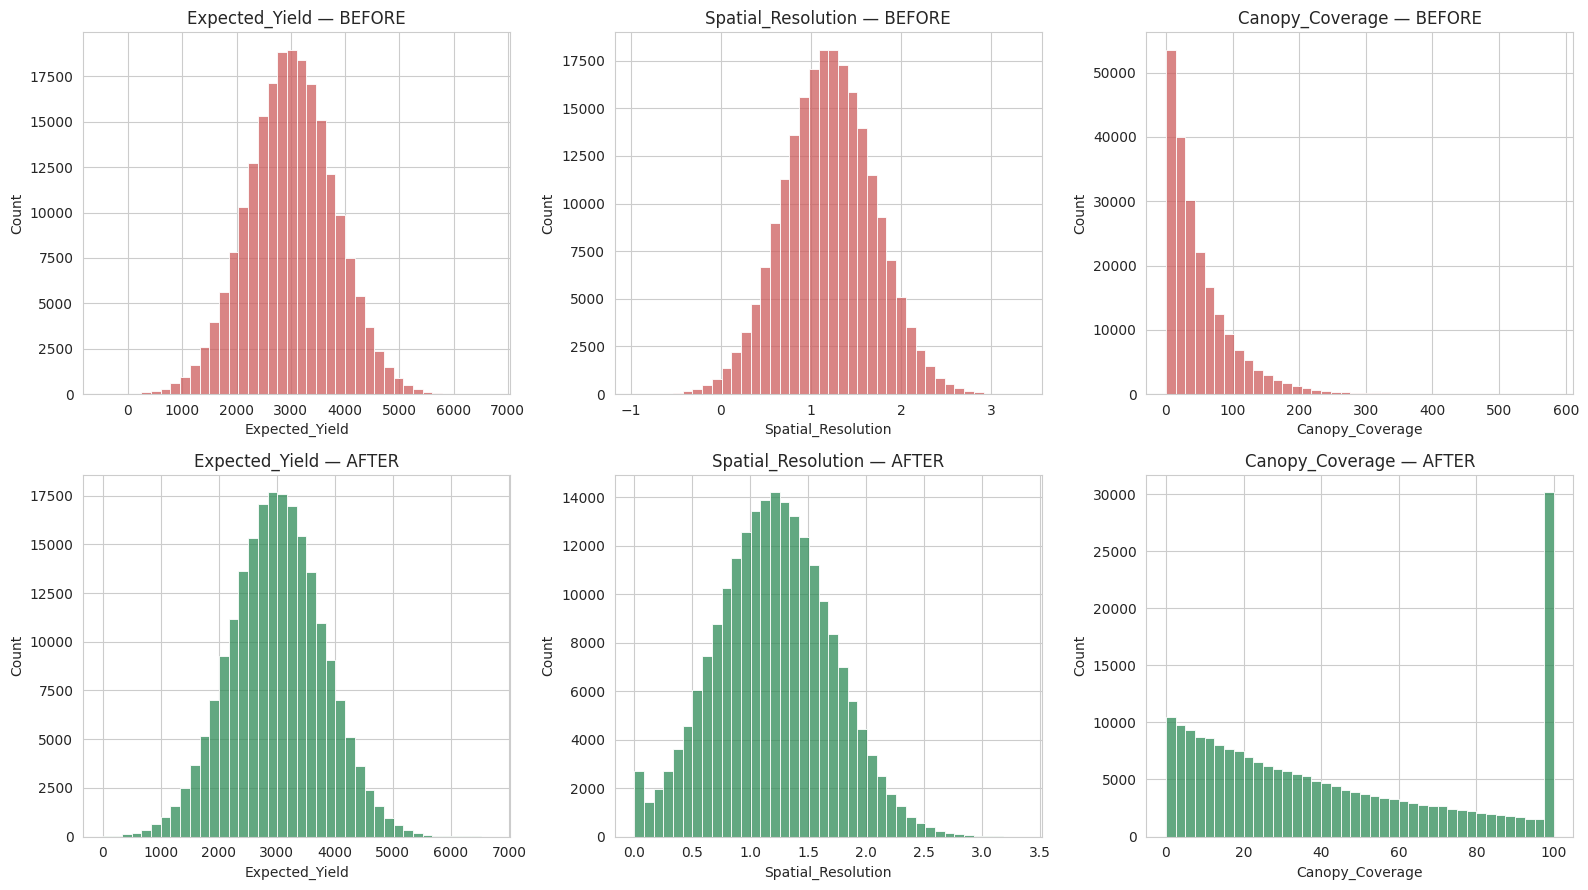

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

pairs = [
    ('Expected_Yield', df_raw['Expected_Yield'], df['Expected_Yield']),
    ('Spatial_Resolution', df_raw['Spatial_Resolution'], df['Spatial_Resolution']),
    ('Canopy_Coverage', df_raw['Canopy_Coverage'], df['Canopy_Coverage']),
]

for i, (name, before, after) in enumerate(pairs):
    sns.histplot(before, bins=40, ax=axes[0, i], color='indianred')
    axes[0, i].set_title(f'{name} — BEFORE')
    sns.histplot(after, bins=40, ax=axes[1, i], color='seagreen')
    axes[1, i].set_title(f'{name} — AFTER')

plt.tight_layout()
plt.show()

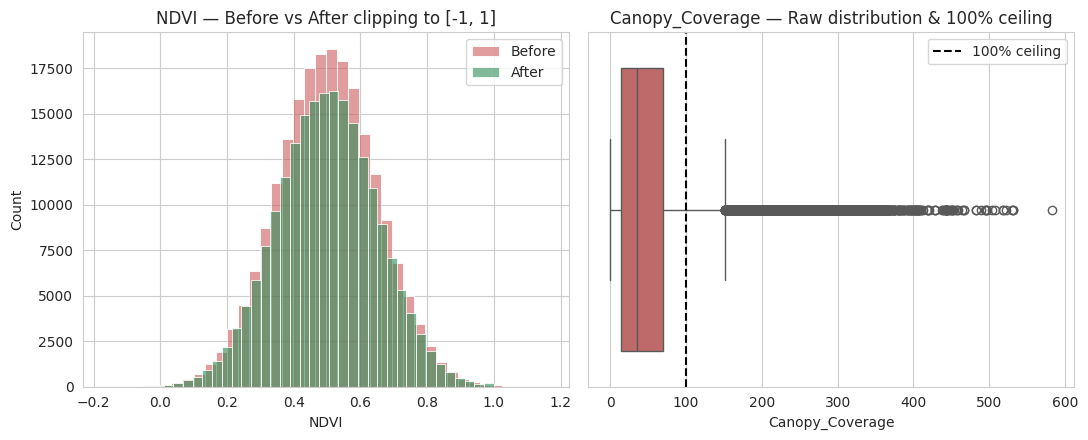

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.histplot(df_raw['NDVI'], bins=40, ax=axes[0], color='indianred', label='Before', alpha=0.6)
sns.histplot(df['NDVI'], bins=40, ax=axes[0], color='seagreen', label='After', alpha=0.6)
axes[0].set_title('NDVI — Before vs After clipping to [-1, 1]')
axes[0].legend()

sns.boxplot(x=df_raw['Canopy_Coverage'], ax=axes[1], color='indianred')
axes[1].axvline(100, color='black', linestyle='--', label='100% ceiling')
axes[1].set_title('Canopy_Coverage — Raw distribution & 100% ceiling')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_484/3662775893.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stage', y='Columns', data=shapes, ax=ax, palette=['indianred', 'seagreen'])


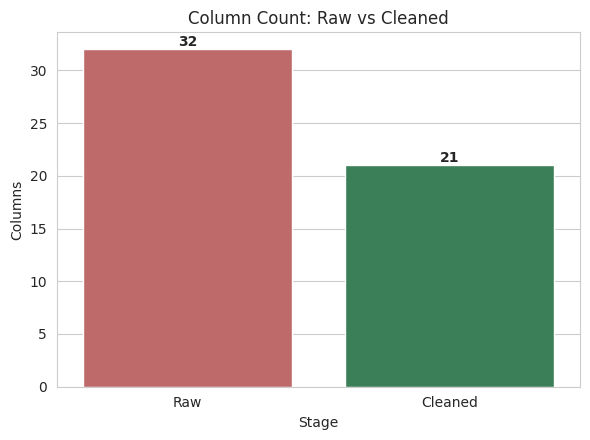

In [29]:
fig, ax = plt.subplots(figsize=(6, 4.5))
shapes = pd.DataFrame({
    'Stage': ['Raw', 'Cleaned'],
    'Columns': [before_shape[1], df_cleaned.shape[1]]
})
sns.barplot(x='Stage', y='Columns', data=shapes, ax=ax, palette=['indianred', 'seagreen'])
ax.set_title('Column Count: Raw vs Cleaned')
for i, v in enumerate(shapes['Columns']):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Note:** Row count is unchanged (212,019 → 212,019) — confirming that no rows were
deleted; every fix was an in-place value correction (clipping) or a column removal.

---
## 8. Save the Cleaned Dataset

In [30]:
output_path = 'cleaned_crop_pest_dataset.csv'
df_cleaned.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")
print(f"Final shape: {df_cleaned.shape[0]} rows x {df_cleaned.shape[1]} columns")

Saved cleaned dataset to: cleaned_crop_pest_dataset.csv
Final shape: 212019 rows x 21 columns


In [31]:
# Quick reload check to confirm the file is valid and readable
check = pd.read_csv(output_path)
print(check.shape)
check.head()

(212019, 21)


,Elevation_Data,Canopy_Coverage,NDVI,SAVI,Chlorophyll_Content,Leaf_Area_Index,Crop_Stress_Indicator,Temperature,Humidity,Rainfall,Wind_Speed,Soil_Moisture,Soil_pH,Organic_Matter,Pest_Hotspots,Weed_Coverage,Pest_Damage,Crop_Growth_Stage,Crop_Type,Water_Flow,Drainage_Features
0,28.207634,8.046926,0.676945,0.475536,0.829063,3.107188,79,24.627325,47.240283,7.056089,2.795500,31.010549,6.085810,2.126335,False,1.922274,84,2,Wheat,41.771884,False
1,82.335147,100.000000,0.414781,0.325712,0.435861,1.287952,88,27.671999,44.408156,14.005230,2.325063,12.429003,6.776880,1.751158,False,4.851381,56,3,Wheat,27.564635,False
2,83.865629,30.246527,0.723610,0.511144,1.001452,1.229495,59,23.515820,56.268020,46.152684,1.705493,28.454713,6.078783,0.365124,False,5.974859,38,1,Maize,29.510836,False
3,20.747905,6.857820,0.405611,0.162857,0.962720,0.995907,11,11.473797,38.637011,15.168736,5.891225,28.450994,6.596315,2.484465,False,2.100598,27,2,Maize,34.822855,False
4,22.588815,26.168558,0.465992,0.269888,2.111205,0.438672,79,22.502605,64.438963,9.492281,2.281165,8.295005,7.664008,3.520753,False,3.025669,84,4,Rice,15.493255,True


---
# Summary of Cleaning Decisions

| # | Issue | Rows Affected | Action Taken | Rationale |
|---|---|---|---|---|
| 1 | `Expected_Yield` negative | 18 (0.008%) | Clipped to 0 | Yield cannot be negative; too few rows to justify deletion |
| 2 | `Spatial_Resolution` negative | 1,738 (0.82%) | Clipped to 0 | Physical measurement cannot be negative |
| 3 | `Canopy_Coverage` > 100% | 28,652 (13.5%) | Clipped to 100 | Percentage is bounded by definition; too many rows to drop |
| 4 | `NDVI` outside [-1, 1] | 108 (0.05%) | Clipped to [-1, 1] | Mathematically bounded index |
| 5 | `SAVI` outside [-1, 1] | 0 | No action | Already valid |
| 6 | Flag/categorical columns stored as int | N/A | Converted `Crop_Type`→category, `Crop_Growth_Stage`→ordered category, `Pest_Hotspots`/`Drainage_Features`→bool | Correct semantics for modeling and analysis |
| 7 | `GPS_Coordinates` | N/A | Investigated, found to be a fake/synthetic ID (not real lat/long) | Removed — no genuine geographic value, risk of leakage as a pseudo-ID |
| 8 | Leakage / metadata columns | N/A | Removed 11 columns (imaging flags, `Spatial_Resolution`, `GPS_Coordinates`, `Field_Boundaries`, `Ground_Truth_Segmentation`, `Bounding_Boxes`, `Expected_Yield`, `Crop_Health_Label`) | Not legitimate causal inputs for pest-risk prediction; several are downstream outcomes or annotation artifacts |
| 9 | Missing values | 0 | None needed | Dataset had zero missing values from the start |
| 10 | Duplicate rows | 0 | None needed | Confirmed zero duplicates both before and after column removal |

**Row count: unchanged at 212,019** — every correction was made via value clipping or
column removal, never row deletion, per the "no blind row deletion" requirement.

**Final cleaned dataset:** `cleaned_crop_pest_dataset.csv` — 212,019 rows × 21 columns,
containing crop context, environmental drivers, remote-sensing indices, and the two
pest-related columns (`Pest_Damage`, `Pest_Hotspots`) needed for the next stages.

**Not done in this notebook (intentionally):**
- No Low/Medium/High target creation
- No model training
- No feature scaling/encoding for ML
These come in later notebooks once cleaning is fully verified.